<a href="https://colab.research.google.com/github/Ssoares06/eda_projeto_ia/blob/main/eda_projeto_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1ª Etapa do Projeto - Análise Exploratória de Dados (EDA)

### 1) **(5%)** Qual a base escolhida e qual seu interesse nela?

*Indique o link da base no Kaggle e explique em um parágrafo curto por que essa base é interessante para você.*


**Base escolhida:** Video Game Sales — https://www.kaggle.com/datasets/gregorut/videogamesales

**Por que ela me interessa:** a indústria de jogos é uma das maiores do entretenimento e movimenta bilhões de dólares por ano. Esta base reúne mais de 16 mil registros de jogos (um por jogo e plataforma) lançados entre 1980 e 2016, com vendas por região, plataforma, gênero e publisher. Isso permite perguntar o que realmente faz um jogo vender bem: o gênero, a plataforma, a época ou a região? Também é uma base com variáveis contínuas, discretas e textuais, o que dá espaço para uma análise exploratória completa.

### 2) **(5%)** Descrição básica do conjunto de dados escolhido pelo aluno (1 parágrafo).
- Identificação da variável a serem trabalhadas
- Classificação das variáveis como: contínua ou discreta.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def carregar_base(nome="vgsales.csv"):
    """Procura o CSV localmente, no Kaggle Notebooks; se não achar, baixa via kagglehub."""
    candidatos = [Path(nome), Path("data") / nome, Path("/kaggle/input/videogamesales") / nome]
    for caminho in candidatos:
        if caminho.exists():
            return pd.read_csv(caminho)
    import kagglehub  # pip install kagglehub
    pasta = Path(kagglehub.dataset_download("gregorut/videogamesales"))
    return pd.read_csv(next(pasta.rglob(nome)))


df_raw = carregar_base()

# ---- Testes de sanidade da base (critérios do enunciado) ----
COLUNAS = ["Rank", "Name", "Platform", "Year", "Genre", "Publisher",
           "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
assert list(df_raw.columns) == COLUNAS, f"Colunas inesperadas: {list(df_raw.columns)}"
assert len(df_raw) > 10_000, "A base precisa ter mais de 10 mil registros"
assert df_raw.shape[1] >= 10, "A base precisa ter 10 ou mais features"
print(f"OK: {df_raw.shape[0]:,} registros e {df_raw.shape[1]} colunas")
df_raw.head()

Using Colab cache for faster access to the 'videogamesales' dataset.
OK: 16,598 registros e 11 colunas


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,"2,006.000",Sports,Nintendo,41.490,29.020,3.770,8.460,82.740
1,2,Super Mario Bros.,NES,"1,985.000",Platform,Nintendo,29.080,3.580,6.810,0.770,40.240
2,3,Mario Kart Wii,Wii,"2,008.000",Racing,Nintendo,15.850,12.880,3.790,3.310,35.820
3,4,Wii Sports Resort,Wii,"2,009.000",Sports,Nintendo,15.750,11.010,3.280,2.960,33.000
4,5,Pokemon Red/Pokemon Blue,GB,"1,996.000",Role-Playing,Nintendo,11.270,8.890,10.220,1.000,31.370


A base **Video Game Sales** contém um registro por jogo e plataforma, com 11 variáveis. Trabalharemos com todas, exceto `Rank`, que é apenas um identificador (posição no ranking de vendas) e não carrega informação analítica própria. As vendas estão em **milhões de unidades**. A classificação das variáveis está na tabela abaixo.

In [2]:
classificacao = pd.DataFrame([
    ("Rank",         "Identificador (posição no ranking)", "Discreta (não usada na análise)"),
    ("Name",         "Texto",                              "Discreta (nominal)"),
    ("Platform",     "Texto / categórica",                 "Discreta (nominal)"),
    ("Year",         "Número inteiro / temporal",          "Discreta (ordinal)"),
    ("Genre",        "Texto / categórica",                 "Discreta (nominal)"),
    ("Publisher",    "Texto / categórica",                 "Discreta (nominal)"),
    ("NA_Sales",     "Número real (milhões de un.)",       "Contínua"),
    ("EU_Sales",     "Número real (milhões de un.)",       "Contínua"),
    ("JP_Sales",     "Número real (milhões de un.)",       "Contínua"),
    ("Other_Sales",  "Número real (milhões de un.)",       "Contínua"),
    ("Global_Sales", "Número real (milhões de un.)",       "Contínua"),
], columns=["Variável", "Tipo de dado", "Classificação"])
classificacao

,Variável,Tipo de dado,Classificação
0,Rank,Identificador (posição no ranking),Discreta (não usada na análise)
1,Name,Texto,Discreta (nominal)
2,Platform,Texto / categórica,Discreta (nominal)
3,Year,Número inteiro / temporal,Discreta (ordinal)
4,Genre,Texto / categórica,Discreta (nominal)
5,Publisher,Texto / categórica,Discreta (nominal)
6,NA_Sales,Número real (milhões de un.),Contínua
7,EU_Sales,Número real (milhões de un.),Contínua
8,JP_Sales,Número real (milhões de un.),Contínua
9,Other_Sales,Número real (milhões de un.),Contínua


### 3) **(15%)** Faça uma avaliação descritiva da sua base. Quantas linhas ela possui? Quais os tipos de dados? Quantas e quais features possuem?

Cada variável escolhida pelo aluno precisa passar por ao menos 1 pré-processamento. O pré-processamento pode ser (mas não está limitado a):
- Checagem se os valores estão dentro de um limite permitido ou razoável.
- Tratamento de valores ausentes por eliminação ou substituição.
- Conversão do tipo de dados.


In [3]:
print("Linhas x colunas:", df_raw.shape)
print("\nTipos de dados originais:")
print(df_raw.dtypes)

print("\nValores nulos (NaN) por coluna:")
print(df_raw.isna().sum())

print("\nTextos 'N/A' (nulos disfarçados) por coluna:")
print((df_raw == "N/A").sum()[lambda s: s > 0])

print("\nLinhas duplicadas:", df_raw.duplicated().sum())
df_raw.describe().T

Linhas x colunas: (16598, 11)

Tipos de dados originais:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Valores nulos (NaN) por coluna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Textos 'N/A' (nulos disfarçados) por coluna:
Series([], dtype: int64)

Linhas duplicadas: 0


,count,mean,std,min,25%,50%,75%,max
Rank,"16,598.000","8,300.605","4,791.854",1.000,"4,151.250","8,300.500","12,449.750","16,600.000"
Year,"16,327.000","2,006.406",5.829,"1,980.000","2,003.000","2,007.000","2,010.000","2,020.000"
NA_Sales,"16,598.000",0.265,0.817,0.000,0.000,0.080,0.240,41.490
EU_Sales,"16,598.000",0.147,0.505,0.000,0.000,0.020,0.110,29.020
JP_Sales,"16,598.000",0.078,0.309,0.000,0.000,0.000,0.040,10.220
Other_Sales,"16,598.000",0.048,0.189,0.000,0.000,0.010,0.040,10.570
Global_Sales,"16,598.000",0.537,1.555,0.010,0.060,0.170,0.470,82.740


**Leitura:** a coluna `Year` foi lida como texto porque contém o valor `"N/A"`, e `Publisher` também traz `"N/A"` como nulo disfarçado. Além disso, as vendas têm distribuição muito assimétrica (média bem acima da mediana), o que influenciará as escolhas de gráficos adiante.

**Pré-processamento aplicado (ao menos um por variável):**

| Variável | Tratamento |
|---|---|
| `Rank` | Mantida só como identificador; validada como única |
| `Name` | Remoção de espaços extras (conversão para `string`) |
| `Platform`, `Genre` | Conversão para tipo `category`; checagem de nulos |
| `Year` | `"N/A"` convertido em nulo, registros nulos eliminados, conversão para inteiro e checagem de faixa razoável (1980–2016, período que a base cobre) |
| `Publisher` | `"N/A"` substituído por `"Unknown"` (substituição, para não perder jogos) |
| `NA/EU/JP/Other/Global_Sales` | Checagem de valores não negativos e de coerência (Global ≈ soma das regiões) |

In [4]:
df = df_raw.copy()

# --- Name: remove espaços extras
df["Name"] = df["Name"].astype("string").str.strip()

# --- Year: "N/A" -> NaN, elimina nulos, converte para int e filtra faixa razoável
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
n_antes = len(df)
df = df.dropna(subset=["Year"])
n_sem_ano = n_antes - len(df)
df["Year"] = df["Year"].astype(int)

fora_faixa = ~df["Year"].between(1980, 2016)
n_fora_faixa = int(fora_faixa.sum())
df = df[~fora_faixa]

# --- Publisher: "N/A" -> "Unknown" (substituição)
df["Publisher"] = df["Publisher"].astype("string").str.strip().replace("N/A", "Unknown").fillna("Unknown")

# --- Platform / Genre: tipo categórico
for col in ["Platform", "Genre"]:
    df[col] = df[col].astype("string").str.strip().astype("category")

# --- Duplicados exatos
n_dup = int(df.duplicated().sum())
df = df.drop_duplicates()

# --- Faixa etária (para as análises de dependência): décadas
df["Era"] = pd.cut(df["Year"], bins=[1979, 1989, 1999, 2009, 2016],
                   labels=["1980-89", "1990-99", "2000-09", "2010-16"])

df = df.reset_index(drop=True)

# ---- Testes pós-limpeza ----
VENDAS = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
assert df["Rank"].is_unique, "Rank deveria ser único"
assert df["Year"].between(1980, 2016).all(), "Ano fora da faixa"
assert (df[VENDAS] >= 0).all().all(), "Há vendas negativas"
assert df[["Name", "Platform", "Genre", "Publisher", "Year"] + VENDAS].notna().all().all(), "Sobraram nulos"
assert (df["Global_Sales"] >= df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].max(axis=1) - 0.01).all(), \
    "Global_Sales menor que alguma região"

diff = (df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1) - df["Global_Sales"]).abs()
print(f"Removidos por Year ausente: {n_sem_ano:,} ({n_sem_ano / n_antes:.1%})")
print(f"Removidos por Year fora de 1980-2016: {n_fora_faixa}")
print(f"Duplicados removidos: {n_dup}")
print(f"Maior diferença |soma das regiões - Global|: {diff.max():.2f} (arredondamento da fonte)")
print(f"\nBase final: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.info()

Removidos por Year ausente: 271 (1.6%)
Removidos por Year fora de 1980-2016: 4
Duplicados removidos: 0
Maior diferença |soma das regiões - Global|: 0.02 (arredondamento da fonte)

Base final: 16,323 linhas x 12 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16323 entries, 0 to 16322
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Rank          16323 non-null  int64   
 1   Name          16323 non-null  string  
 2   Platform      16323 non-null  category
 3   Year          16323 non-null  int64   
 4   Genre         16323 non-null  category
 5   Publisher     16323 non-null  string  
 6   NA_Sales      16323 non-null  float64 
 7   EU_Sales      16323 non-null  float64 
 8   JP_Sales      16323 non-null  float64 
 9   Other_Sales   16323 non-null  float64 
 10  Global_Sales  16323 non-null  float64 
 11  Era           16323 non-null  category
dtypes: category(3), float64(5), int64(2), string(2)
mem

### 4) **(60%)** Nos blocos seguintes construa análises que vão justificar suas conclusões.

#### 4.1) **(20%)** Análise 1 -  Distribuição dos valores para cada uma das variáveis
- Exemplo para variável contínua: se o conjunto de dados possui a variável "idade". Quantos % possui a idade entre 0 e 30 anos? 31 a 59? 60+?

- Exemplo para variável discreta: se o conjunto de dados possui a variável "gênero", quantos % do conjunto de dados é do sexo feminino, quantos % é masculino? Inclua outros gêneros se houver.


,Qtde,%
Global_Sales,,
"< 0,1M",5675,34.770
"0,1 a 0,5M",6683,40.940
"0,5 a 1M",1906,11.680
1 a 5M,1853,11.350
5M+,206,1.260


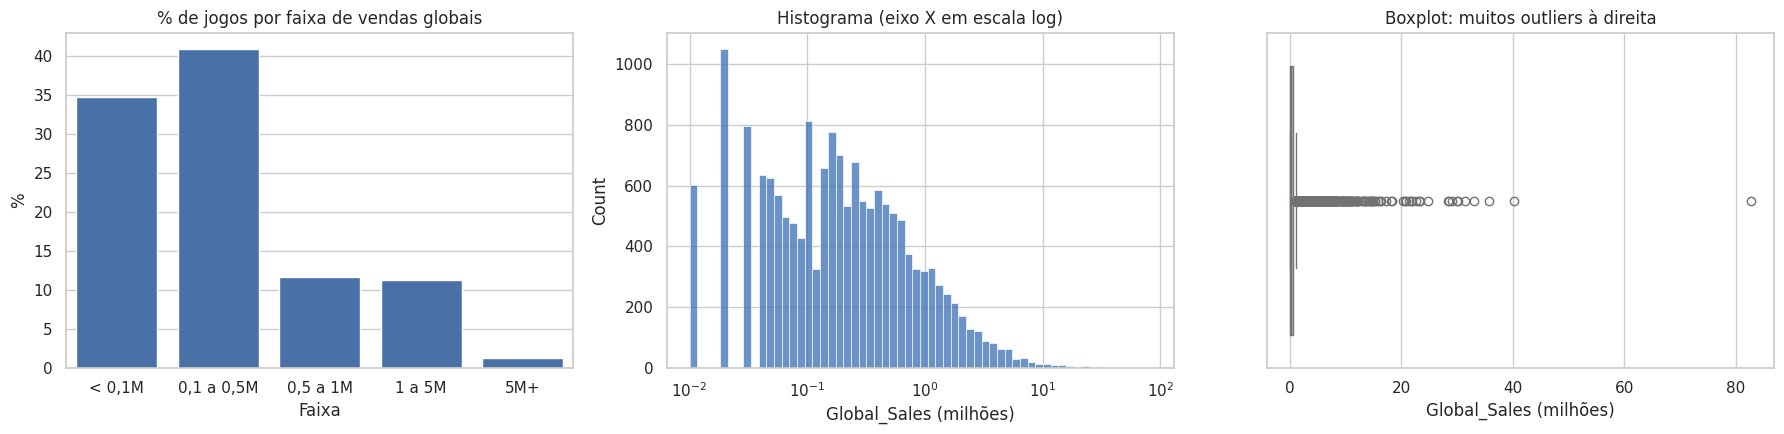

,% das vendas totais,% de jogos com venda zero (arredondada),Média (M),Mediana (M)
NA_Sales,49.150,27.180,0.265,0.080
EU_Sales,27.330,34.450,0.148,0.020
JP_Sales,14.570,62.730,0.079,0.000
Other_Sales,8.950,38.970,0.048,0.010


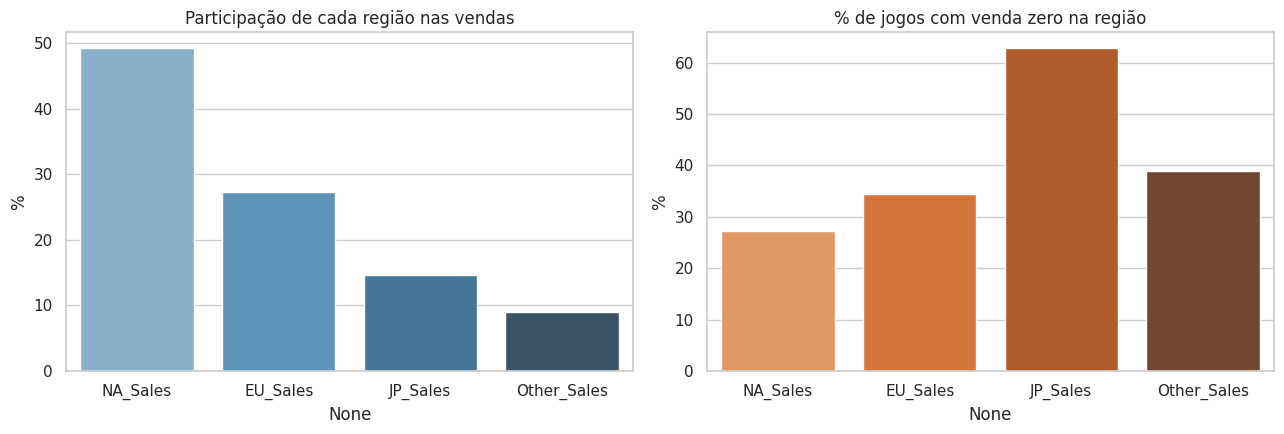

In [5]:
def tabela_pct(serie, nome="%"):
    """Contagem e percentual de cada valor de uma série."""
    c = serie.value_counts()
    return pd.DataFrame({"Qtde": c, nome: (c / c.sum() * 100).round(2)})


# ============ VARIÁVEL CONTÍNUA: Global_Sales ============
faixas = pd.cut(df["Global_Sales"], bins=[0, 0.1, 0.5, 1, 5, np.inf],
                labels=["< 0,1M", "0,1 a 0,5M", "0,5 a 1M", "1 a 5M", "5M+"],
                right=False, include_lowest=True)
dist_global = tabela_pct(faixas).sort_index()
assert abs(dist_global.iloc[:, 1].sum() - 100) < 0.1
display(dist_global)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.barplot(x=dist_global.index.astype(str), y=dist_global.iloc[:, 1], ax=ax[0], color="#3b6fb6")
ax[0].set(title="% de jogos por faixa de vendas globais", xlabel="Faixa", ylabel="%")
sns.histplot(df["Global_Sales"], bins=60, log_scale=True, ax=ax[1], color="#3b6fb6")
ax[1].set(title="Histograma (eixo X em escala log)", xlabel="Global_Sales (milhões)")
sns.boxplot(x=df["Global_Sales"], ax=ax[2], color="#9bb8e0")
ax[2].set(title="Boxplot: muitos outliers à direita", xlabel="Global_Sales (milhões)")
plt.tight_layout(); plt.show()

# ============ VARIÁVEIS CONTÍNUAS: vendas por região ============
regioes = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
resumo = pd.DataFrame({
    "% das vendas totais": (df[regioes].sum() / df[regioes].sum().sum() * 100).round(2),
    "% de jogos com venda zero (arredondada)": ((df[regioes] == 0).mean() * 100).round(2),
    "Média (M)": df[regioes].mean(),
    "Mediana (M)": df[regioes].median(),
})
display(resumo)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=resumo.index, y=resumo["% das vendas totais"], ax=ax[0], palette="Blues_d")
ax[0].set(title="Participação de cada região nas vendas", ylabel="%")
sns.barplot(x=resumo.index, y=resumo["% de jogos com venda zero (arredondada)"], ax=ax[1], palette="Oranges_d")
ax[1].set(title="% de jogos com venda zero na região", ylabel="%")
plt.tight_layout(); plt.show()

,Qtde,%
Genre,,
Action,3252,19.920
Sports,2304,14.120
Misc,1710,10.480
Role-Playing,1469,9.000
Shooter,1282,7.850
Adventure,1276,7.820
Racing,1226,7.510
Platform,876,5.370
Simulation,850,5.210


,Qtde,%
DS,2132,13.060
PS2,2127,13.030
PS3,1304,7.990
Wii,1290,7.900
X360,1235,7.570
PSP,1197,7.330
PS,1189,7.280
PC,943,5.780
GBA,811,4.970
XB,803,4.920


,Qtde,%
Era,,
1980-89,205,1.260
1990-99,1769,10.840
2000-09,9208,56.410
2010-16,5141,31.500


,Qtde,%
Publisher,,
Electronic Arts,1339,8.200
Activision,966,5.920
Namco Bandai Games,928,5.690
Ubisoft,917,5.620
Konami Digital Entertainment,823,5.040
THQ,712,4.360
Nintendo,696,4.260
Sony Computer Entertainment,682,4.180
Sega,630,3.860


Publishers distintos: 576 | Top 10 concentram 49.6% dos lançamentos


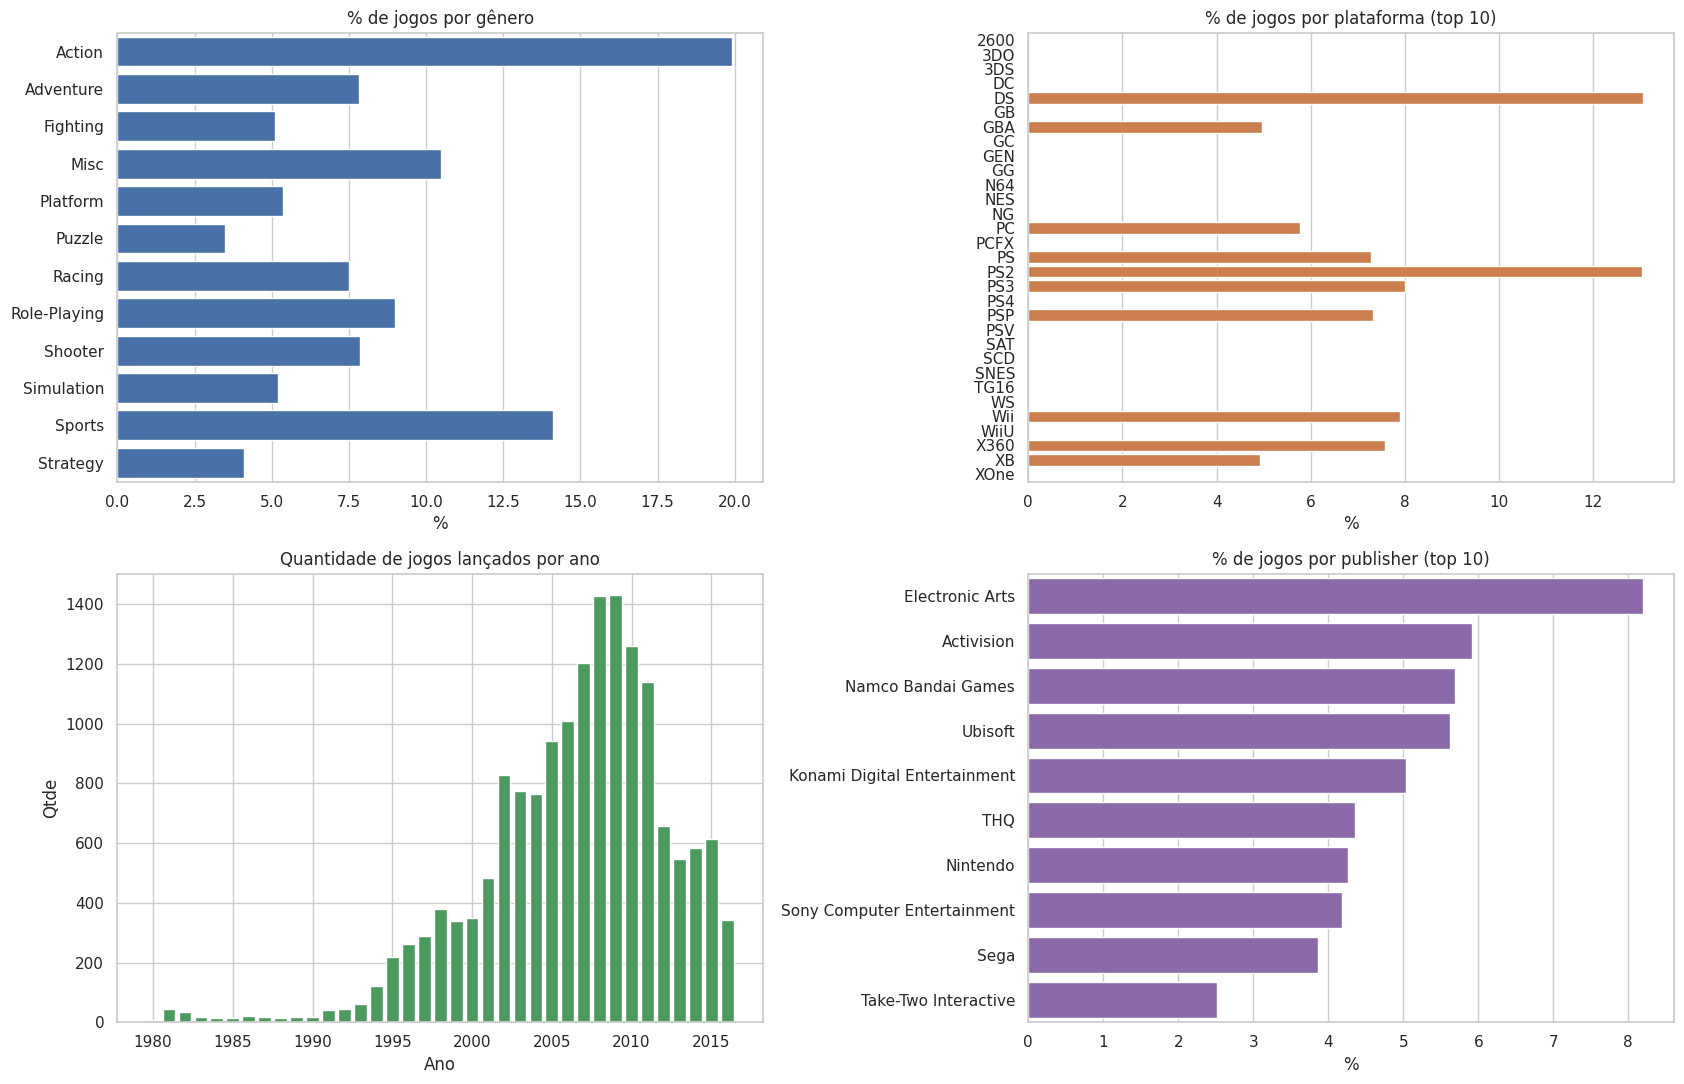

In [6]:
# ============ VARIÁVEL DISCRETA: Genre ============
dist_genero = tabela_pct(df["Genre"])
display(dist_genero)

# ============ VARIÁVEL DISCRETA: Platform (top 10 + Outras) ============
dist_plat = tabela_pct(df["Platform"])
top_plat = dist_plat.head(10)
outras = pd.DataFrame({"Qtde": [dist_plat["Qtde"].iloc[10:].sum()],
                       "%": [dist_plat["%"].iloc[10:].sum()]}, index=["Outras"])
display(pd.concat([top_plat, outras]))

# ============ VARIÁVEL DISCRETA: Year (por década) ============
dist_era = tabela_pct(df["Era"]).sort_index()
display(dist_era)

# ============ VARIÁVEL DISCRETA: Publisher (top 10) ============
dist_pub = tabela_pct(df["Publisher"])
display(dist_pub.head(10))
print(f"Publishers distintos: {df['Publisher'].nunique():,} | "
      f"Top 10 concentram {dist_pub['%'].head(10).sum():.1f}% dos lançamentos")

fig, ax = plt.subplots(2, 2, figsize=(17, 11))
sns.barplot(y=dist_genero.index, x=dist_genero["%"], ax=ax[0, 0], color="#3b6fb6")
ax[0, 0].set(title="% de jogos por gênero", xlabel="%", ylabel="")
sns.barplot(y=top_plat.index, x=top_plat["%"], ax=ax[0, 1], color="#e07b39")
ax[0, 1].set(title="% de jogos por plataforma (top 10)", xlabel="%", ylabel="")
por_ano = df["Year"].value_counts().sort_index()
ax[1, 0].bar(por_ano.index, por_ano.values, color="#4c9a5f")
ax[1, 0].set(title="Quantidade de jogos lançados por ano", xlabel="Ano", ylabel="Qtde")
sns.barplot(y=dist_pub.head(10).index, x=dist_pub["%"].head(10), ax=ax[1, 1], color="#8a5fb3")
ax[1, 1].set(title="% de jogos por publisher (top 10)", xlabel="%", ylabel="")
plt.tight_layout(); plt.show()

**Leitura da Análise 1:**

- **Vendas globais:** a base é muito concentrada nas faixas baixas. Cerca de 35% dos jogos vendem menos de 0,1M, e 76% vendem menos de 0,5M. Só cerca de 12,6% chegam a 1M ou mais, e apenas 1,3% passam de 5M. Por isso a média fica bem acima da mediana e o boxplot tem tantos outliers à direita.
- **Regiões:** a América do Norte lidera, com cerca de 49% das vendas totais, seguida da Europa (27%), do Japão (15%) e dos demais mercados (9%). O Japão tem 63% dos jogos com venda zero, o que indica que muitos títulos nem chegam a ser vendidos lá.
- **Gênero:** `Action` é o mais frequente (cerca de 20% dos registros), seguido de `Sports` (14%) e `Misc` (10%). `Puzzle` e `Strategy` são os menos frequentes.
- **Plataforma:** DS e PS2 lideram, com cerca de 13% cada, e as 10 maiores plataformas somam cerca de 80% dos registros.
- **Período:** 56% dos jogos são de 2000–2009, e o pico de lançamentos é em 2009. Os anos 1980 representam apenas 1,3% da base.
- **Publisher:** são 576 publishers distintos, e os 10 maiores concentram cerca de 50% dos lançamentos, com a Electronic Arts à frente (8,2%).

#### 4.2) **(20%)** Análise 2 - Dependência entre variáveis
O aluno deve apresentar as mesmas distribuições para cada valor da variável dependente. Exemplo: Em um conjunto de dados em que as variáveis independentes são idade e sexo, e a variável dependente é renda. O aluno pode dividir a renda em 3 "grupos", <1000 reais, entre 1000 e 10000 reais e >1000 reais. Para cada um desses grupos, é necessário apresentar a distribuição das variáveis "idade" e "sexo".


**Variável dependente:** `Global_Sales`, dividida em 3 grupos: **Nicho** (< 0,1M), **Médio** (0,1 a 1M) e **Hit** (≥ 1M). Para cada grupo apresentamos a distribuição (em %) de `Genre`, `Platform` e `Era` (período de lançamento).

,Qtde,%
Grupo_Vendas,,
"Nicho (<0,1M)",5675,34.770
"Médio (0,1-1M)",8589,52.620
Hit (>=1M),2059,12.610



=== Distribuição de Gênero por grupo de vendas (%) ===


Grupo_Vendas,"Nicho (<0,1M)","Médio (0,1-1M)",Hit (>=1M)
Genre,,,
Action,18.100,21.030,20.350
Adventure,14.150,5.040,1.940
Fighting,4.190,5.530,5.970
Misc,10.710,10.860,8.210
Platform,3.980,5.310,9.420
Puzzle,4.850,2.790,2.720
Racing,6.710,7.730,8.790
Role-Playing,8.560,9.080,9.860
Shooter,6.640,7.640,12.090



=== Distribuição de Plataforma por grupo de vendas (%) ===


Grupo_Vendas,"Nicho (<0,1M)","Médio (0,1-1M)",Hit (>=1M)
Platform_top,,,
DS,16.950,11.950,6.990
Outras,29.530,30.280,30.550
PC,11.190,2.790,3.300
PS,4.780,8.310,9.910
PS2,10.560,14.060,15.540
PS3,5.180,8.900,11.950
PSP,11.120,5.940,2.720
Wii,6.290,9.030,7.630
X360,4.410,8.730,11.410



=== Distribuição de Período (Era) por grupo de vendas (%) ===


Grupo_Vendas,"Nicho (<0,1M)","Médio (0,1-1M)",Hit (>=1M)
Era,,,
1980-89,0.110,1.200,4.660
1990-99,7.240,11.850,16.510
2000-09,56.070,57.890,51.190
2010-16,36.580,29.060,27.630


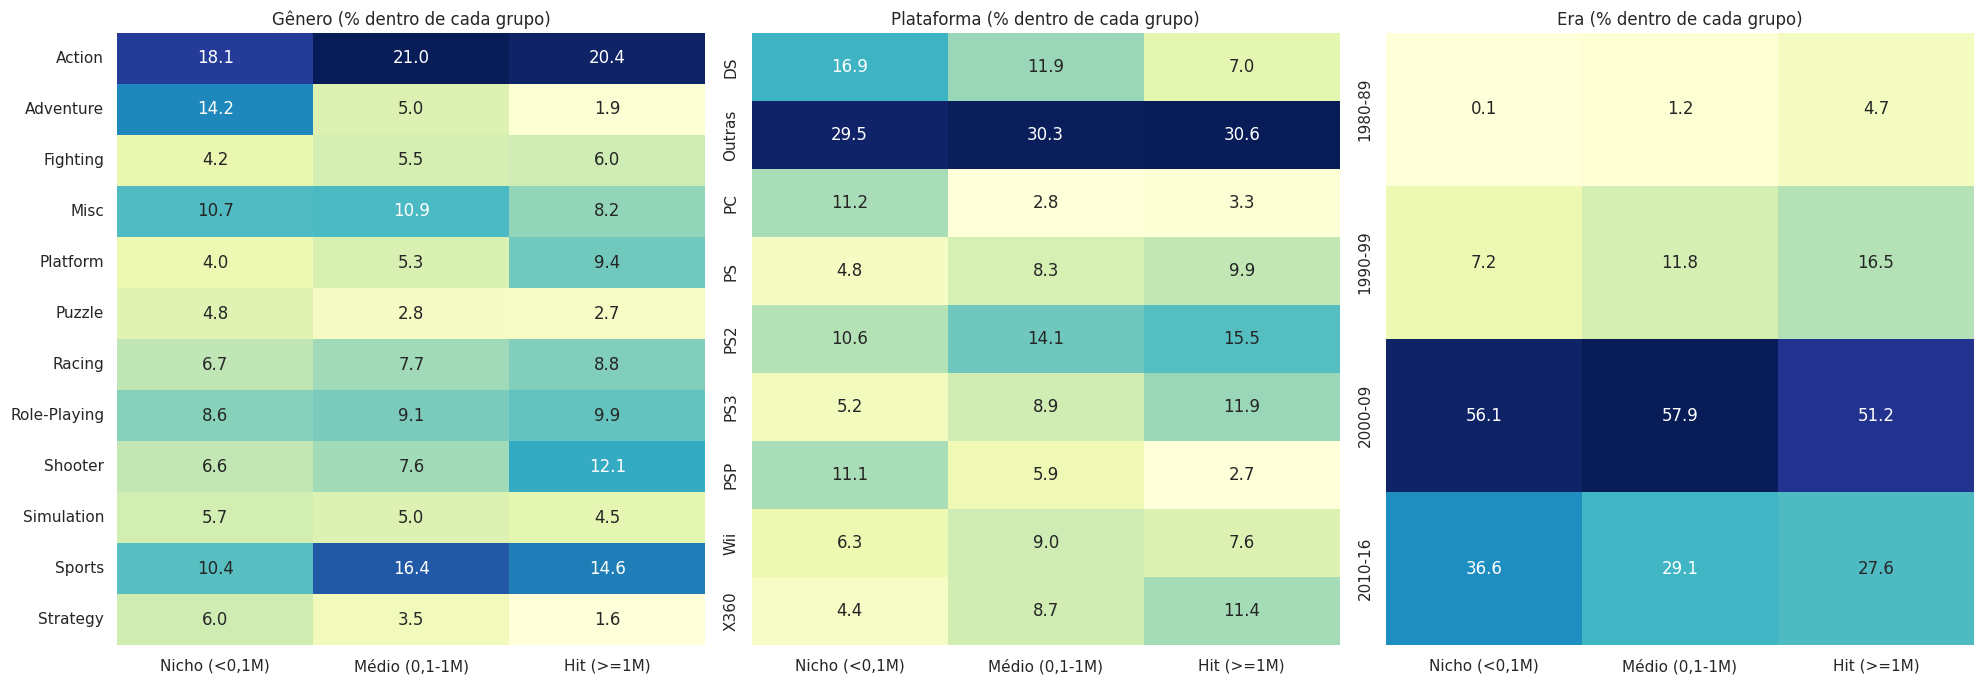

In [7]:
df["Grupo_Vendas"] = pd.cut(df["Global_Sales"], bins=[0, 0.1, 1, np.inf],
                            labels=["Nicho (<0,1M)", "Médio (0,1-1M)", "Hit (>=1M)"],
                            right=False, include_lowest=True)
assert df["Grupo_Vendas"].notna().all()
display(tabela_pct(df["Grupo_Vendas"]).sort_index())

# Plataformas: top 8 + "Outras", para legibilidade
top8 = df["Platform"].value_counts().head(8).index
df["Platform_top"] = df["Platform"].astype("string").where(df["Platform"].isin(top8), "Outras")


def dist_por_grupo(coluna):
    """% de cada valor de `coluna` DENTRO de cada grupo de vendas (colunas somam 100)."""
    t = pd.crosstab(df[coluna], df["Grupo_Vendas"], normalize="columns") * 100
    assert np.allclose(t.sum(), 100), "Cada grupo deve somar 100%"
    return t.round(2)


dep_genero = dist_por_grupo("Genre")
dep_plat = dist_por_grupo("Platform_top")
dep_era = dist_por_grupo("Era")

for titulo, t in [("Gênero", dep_genero), ("Plataforma", dep_plat), ("Período (Era)", dep_era)]:
    print(f"\n=== Distribuição de {titulo} por grupo de vendas (%) ===")
    display(t)

fig, ax = plt.subplots(1, 3, figsize=(20, 7))
for a, (titulo, t) in zip(ax, [("Gênero", dep_genero), ("Plataforma", dep_plat), ("Era", dep_era)]):
    sns.heatmap(t, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False, ax=a)
    a.set(title=f"{titulo} (% dentro de cada grupo)", xlabel="", ylabel="")
plt.tight_layout(); plt.show()

In [8]:
# Versão interativa (Plotly): gênero dentro de cada grupo de vendas
g = dep_genero.reset_index().melt(id_vars="Genre", var_name="Grupo", value_name="%")
fig = px.bar(g, x="Grupo", y="%", color="Genre", barmode="stack",
             title="Composição de gêneros por grupo de vendas (%)")
fig.show()

**Leitura da Análise 2:** a composição dos grupos muda bastante, o que indica relação entre as variáveis independentes e o nível de vendas.

- **Gênero:** `Action` aparece em proporção parecida nos três grupos (cerca de 18 a 21%), então não distingue hits de jogos de nicho. Já `Shooter` (6,6% no nicho contra 12,1% entre os hits) e `Platform` (4,0% contra 9,4%) ficam mais frequentes à medida que as vendas sobem. O contrário ocorre com `Adventure` (14,2% no nicho contra 1,9% entre os hits) e `Strategy` (6,0% contra 1,6%).
- **Plataforma:** X360, PS3 e PS2 têm participação maior entre os hits (por exemplo, X360 vai de 4,4% no nicho a 11,4% nos hits). DS, PSP e PC são mais comuns no nicho (o PC cai de 11,2% para 3,3%).
- **Período:** os anos 1980 e 1990 são raros na base, mas estão sobre-representados entre os hits (1980–89: 0,1% no nicho contra 4,7% nos hits). Já 2010–16 pesa mais no nicho (36,6%) do que entre os hits (27,6%).

#### 4.3) **(20%)** Análise 3 - Correlação entre variáveis

O aluno deve apresentar 3 análises de correlação entre variáveis do conjunto de dados trabalhado. Exemplo: Em um conjunto de dados com as informações de temperatura e ocorrência de incêndios, eu gostaria de saber a incidência de correlação entre as duas variáveis.



1) NA_Sales x Global_Sales  | Pearson 0.941 | Spearman 0.795 -> forte (positiva)
2) JP_Sales x NA_Sales      | Pearson 0.451 | Spearman -0.226 (distorcido: muitos empates em zero no Japão)
   Apenas jogos vendidos nas duas regiões (n=2,667) | Pearson 0.501 | Spearman 0.209 -> fraca (positiva)
3) Year x Global_Sales      | Pearson -0.075 | Spearman -0.151 -> muito fraca (negativa)


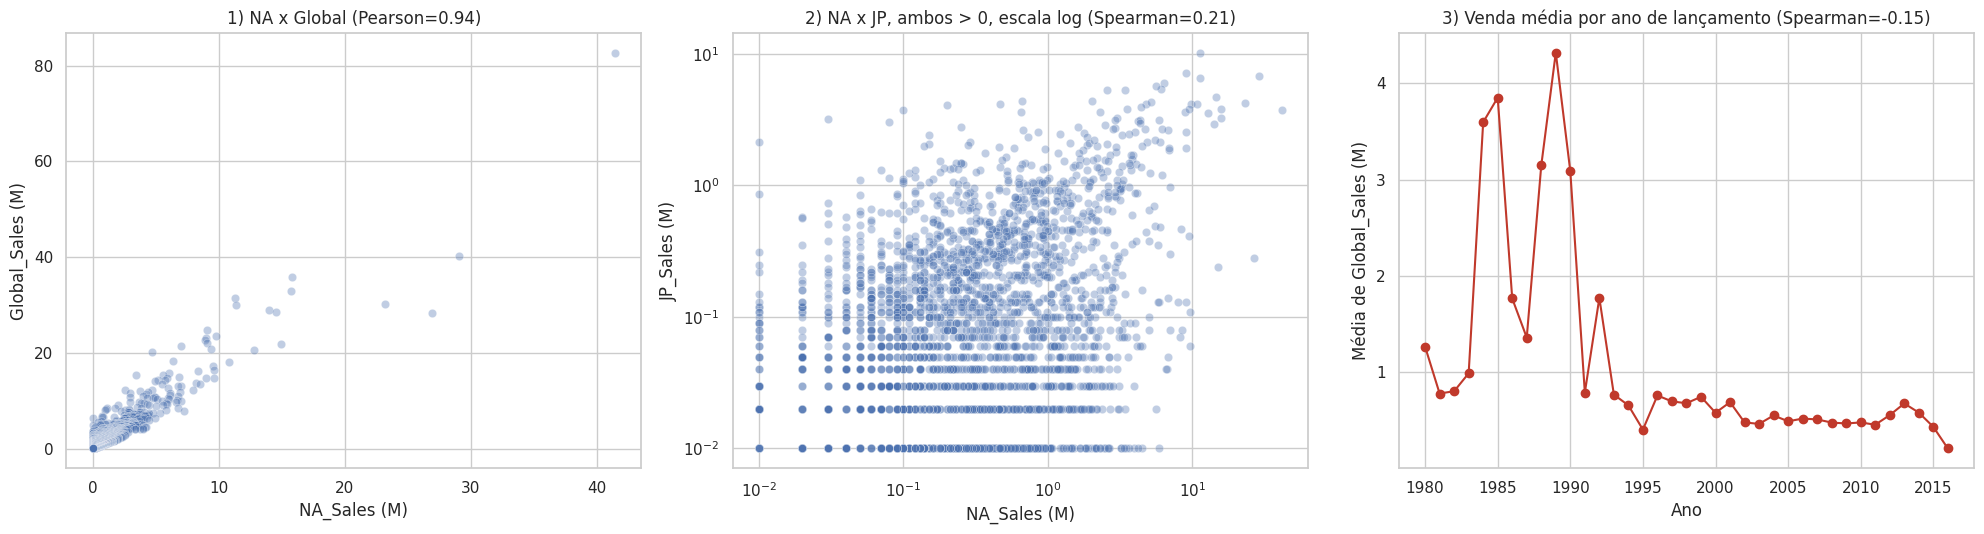

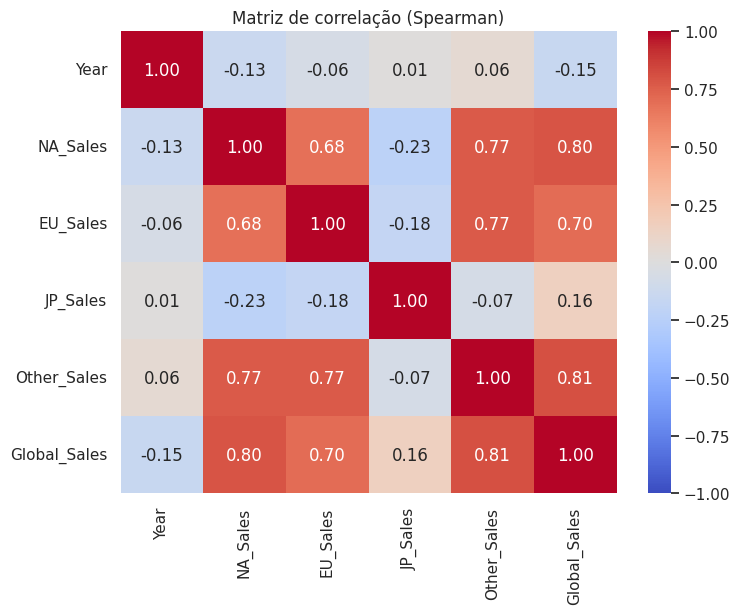

In [9]:
def forca(r):
    a = abs(r)
    nivel = "muito fraca" if a < 0.2 else "fraca" if a < 0.4 else "moderada" if a < 0.7 else "forte"
    return f"{nivel} ({'positiva' if r > 0 else 'negativa'})"


def correlacao(x, y):
    return x.corr(y, method="pearson"), x.corr(y, method="spearman")


# ---------- Correlação 1: NA_Sales x Global_Sales ----------
p1, s1 = correlacao(df["NA_Sales"], df["Global_Sales"])
# ---------- Correlação 2: JP_Sales x NA_Sales ----------
p2, s2 = correlacao(df["JP_Sales"], df["NA_Sales"])
mask = (df["JP_Sales"] > 0) & (df["NA_Sales"] > 0)
p2b, s2b = correlacao(df.loc[mask, "JP_Sales"], df.loc[mask, "NA_Sales"])
# ---------- Correlação 3: Year x Global_Sales ----------
p3, s3 = correlacao(df["Year"].astype(float), df["Global_Sales"])

for r in (p1, s1, p2, s2, p2b, s2b, p3, s3):
    assert -1 <= r <= 1

print(f"1) NA_Sales x Global_Sales  | Pearson {p1:.3f} | Spearman {s1:.3f} -> {forca(p1)}")
print(f"2) JP_Sales x NA_Sales      | Pearson {p2:.3f} | Spearman {s2:.3f} (distorcido: muitos empates em zero no Japão)")
print(f"   Apenas jogos vendidos nas duas regiões (n={mask.sum():,}) | Pearson {p2b:.3f} | Spearman {s2b:.3f} -> {forca(s2b)}")
print(f"3) Year x Global_Sales      | Pearson {p3:.3f} | Spearman {s3:.3f} -> {forca(s3)}")

fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
sns.scatterplot(data=df, x="NA_Sales", y="Global_Sales", alpha=0.35, ax=ax[0])
ax[0].set(title=f"1) NA x Global (Pearson={p1:.2f})", xlabel="NA_Sales (M)", ylabel="Global_Sales (M)")

sns.scatterplot(data=df[mask], x="NA_Sales", y="JP_Sales", alpha=0.35, ax=ax[1])
ax[1].set(xscale="log", yscale="log",
          title=f"2) NA x JP, ambos > 0, escala log (Spearman={s2b:.2f})",
          xlabel="NA_Sales (M)", ylabel="JP_Sales (M)")

media_ano = df.groupby("Year")["Global_Sales"].mean()
ax[2].plot(media_ano.index, media_ano.values, marker="o", color="#c0392b")
ax[2].set(title=f"3) Venda média por ano de lançamento (Spearman={s3:.2f})",
          xlabel="Ano", ylabel="Média de Global_Sales (M)")
plt.tight_layout(); plt.show()

# Visão geral: matriz de correlação (Spearman, robusta a outliers)
cols_num = ["Year", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_num].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação (Spearman)")
plt.show()

**Leitura da Análise 3:**

1. **NA_Sales x Global_Sales:** correlação forte e positiva (Pearson ≈ 0,94 e Spearman ≈ 0,80). Era esperado, porque a América do Norte é a maior região e entra diretamente na soma global. O desempenho nos EUA e no Canadá praticamente "puxa" o resultado global.
2. **JP_Sales x NA_Sales:** como cerca de 63% dos jogos têm venda zero no Japão, o Spearman calculado sobre toda a base (≈ −0,23) é distorcido por empates e não deve ser interpretado. Considerando apenas os jogos vendidos nas duas regiões, a correlação é fraca a moderada (Pearson ≈ 0,50 e Spearman ≈ 0,21), bem mais baixa que a do item 1. O mercado japonês tem gosto próprio, e o sucesso no Ocidente não garante sucesso no Japão.
3. **Year x Global_Sales:** correlação muito fraca e levemente negativa (Pearson ≈ −0,08 e Spearman ≈ −0,15). Não há relação linear simples com o tempo. Jogos mais antigos têm venda média um pouco maior, e o catálogo cresce muito nos anos 2000, diluindo a média.

**Cuidado:** correlação não implica causalidade. Como as vendas são muito assimétricas, o Spearman (por postos) é mais robusto que o Pearson, exceto quando há muitos empates, como no item 2.

### 5) Conclusões **15%**

*O que é possível concluir com os dados que você analisou? Se fosse fazer uma apresentação, o que levaria como os maiores destaques e por que?*

In [10]:
# Números-chave que sustentam as conclusões (rode para conferir o texto abaixo)
ordenado = df["Global_Sales"].sort_values(ascending=False)
n = len(ordenado)
print(f"Jogos analisados: {n:,}")
print(f"Jogos com menos de 0,5M vendidos: {(df['Global_Sales'] < 0.5).mean():.1%}")
print(f"Jogos 'Hit' (>=1M): {(df['Global_Sales'] >= 1).mean():.1%}")
print(f"Top 1% dos jogos concentra {ordenado.head(int(n * 0.01)).sum() / ordenado.sum():.1%} das vendas")
print(f"Top 10% dos jogos concentra {ordenado.head(int(n * 0.10)).sum() / ordenado.sum():.1%} das vendas")
print(f"Região líder: {df[regioes].sum().idxmax()} ({df[regioes].sum().max() / df[regioes].sum().sum():.1%} das vendas)")
print(f"Gênero mais frequente: {df['Genre'].value_counts().idxmax()}")
print(f"Gênero com maior venda média: {df.groupby('Genre')['Global_Sales'].mean().idxmax()}")
print(f"Ano com mais lançamentos: {df['Year'].value_counts().idxmax()}")
print("\nVenda média por gênero (M):")
display(df.groupby("Genre")["Global_Sales"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))

Jogos analisados: 16,323
Jogos com menos de 0,5M vendidos: 75.7%
Jogos 'Hit' (>=1M): 12.6%
Top 1% dos jogos concentra 21.1% das vendas
Top 10% dos jogos concentra 58.9% das vendas
Região líder: NA_Sales (49.2% das vendas)
Gênero mais frequente: Action
Gênero com maior venda média: Platform
Ano com mais lançamentos: 2009

Venda média por gênero (M):


,count,mean,median
Genre,,,
Platform,876,0.947,0.280
Shooter,1282,0.800,0.230
Role-Playing,1469,0.629,0.190
Racing,1226,0.593,0.190
Sports,2304,0.568,0.220
Fighting,836,0.531,0.210
Action,3252,0.530,0.190
Misc,1710,0.466,0.160
Simulation,850,0.459,0.160


**Principais conclusões e destaques para uma apresentação:**

1. **O mercado de jogos é de "cauda longa": poucos hits, muitos títulos modestos.** Cerca de 76% dos jogos vendem menos de meio milhão de cópias, e só 12,6% chegam a 1 milhão. Em contrapartida, o top 10% dos jogos concentra cerca de 59% das vendas totais, e o top 1% sozinho, cerca de 21%. Este é o destaque principal porque muda a forma de ler as médias: a mediana descreve o jogo típico melhor que a média.

2. **A América do Norte domina as vendas e "puxa" o resultado global.** Ela responde por cerca de 49% das vendas, e a correlação com as vendas globais é forte (Pearson ≈ 0,94). O Japão se comporta de forma diferente: 63% dos jogos têm venda zero lá, e a correlação com a América do Norte é bem mais baixa (cerca de 0,50 de Pearson nos jogos vendidos nas duas regiões). Mercados regionais têm preferências distintas.

3. **Frequência não é sinônimo de sucesso.** `Action` é o gênero com mais lançamentos (cerca de 20%), mas a maior venda média por título é de `Platform` (0,95M), seguido de `Shooter` (0,80M). `Adventure` e `Strategy` têm muitos títulos e as menores médias, e são raros entre os hits. A composição dos hits difere da composição do catálogo geral.

4. **O tempo importa, mas não de forma linear.** Os lançamentos crescem até o pico de 2009 e depois caem, e a correlação entre ano e vendas é muito fraca e levemente negativa. Os anos 1980 e 1990 são minoria na base, mas estão sobre-representados entre os hits.

5. **Limitações:** a base cobre apenas vendas físicas até 2016 (sem downloads digitais, mobile e jogos como serviço), e os registros mais recentes podem estar incompletos. Além disso, cada linha é um jogo em uma plataforma, então um mesmo título pode aparecer mais de uma vez. As conclusões valem para esse recorte histórico, não para o mercado atual.

**Próximos passos possíveis:** incluir a análise de publishers (ex.: Nintendo) e comparar plataformas por geração de consoles.